In [288]:
from bs4 import BeautifulSoup as BS
import requests

%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd

#### Menggunakan data dari csv

In [289]:
data_GDP = pd.read_csv ('data_GDP.csv')
data_GDP

,Year,GDP
0,1967,5.667757e+09
1,1968,7.076465e+09
2,1969,8.337423e+09
3,1970,9.150685e+09
4,1971,9.333536e+09
5,1972,1.099759e+10
6,1973,1.627325e+10
7,1974,2.580241e+10
8,1975,3.046386e+10
9,1976,3.726916e+10


#### ambil data dari Web

In [290]:
#url = 'https://www.worldometers.info/gdp/indonesia-gdp/'
#web = requests.get (url)

In [291]:
#scrap = BS (web.text, 'html')
#print (scrap.prettify)

In [292]:
#indicator = scrap.find_all ('th')
#table_title_indicator = [ind.text.strip() for ind in indicator]
#print (table_title_indicator)

In [293]:

#df = pd.DataFrame (
#    columns = table_title_indicator
#)
#df


In [294]:
'''
colom_data = scrap.find_all ('tr')

for row in colom_data[3:]:

    row_data = row.find_all ('td')
    data = [ind.text.strip() for ind in row_data]
    
    n = len (df)
    df.loc[n] = data
'''

"\ncolom_data = scrap.find_all ('tr')\n\nfor row in colom_data[3:]:\n\n    row_data = row.find_all ('td')\n    data = [ind.text.strip() for ind in row_data]\n    \n    n = len (df)\n    df.loc[n] = data\n"

In [295]:
#df_reordered = df.iloc[::-1].reset_index(drop=True)
#df_reordered

In [296]:
#df_reordered.to_csv ('PDB_Indonesia_1993-2022.csv', index=False)

In [297]:
'''
def clean_year (year):
    year = year.astype (int)
    return year

def clean_value (value):
    value = value.astype (str)
    value = value.str.replace('[\$,]', '', regex=True).astype(float)
    return value

df_reordered['Year'] = clean_year (df_reordered['Year'])
df_reordered['GDP Nominal (Current USD)'] = clean_value (df_reordered['GDP Nominal (Current USD)'])
df_reordered['Population'] = (df_reordered['Population'])
#df_reordered['GDP change'] = (df_reordered['GDP change'].str.replace('[\%,]', '', regex=True).astype(float))
df_reordered['GDP per capita'] = clean_value (df_reordered['GDP per capita'])
'''

"\ndef clean_year (year):\n    year = year.astype (int)\n    return year\n\ndef clean_value (value):\n    value = value.astype (str)\n    value = value.str.replace('[\\$,]', '', regex=True).astype(float)\n    return value\n\ndf_reordered['Year'] = clean_year (df_reordered['Year'])\ndf_reordered['GDP Nominal (Current USD)'] = clean_value (df_reordered['GDP Nominal (Current USD)'])\ndf_reordered['Population'] = (df_reordered['Population'])\n#df_reordered['GDP change'] = (df_reordered['GDP change'].str.replace('[\\%,]', '', regex=True).astype(float))\ndf_reordered['GDP per capita'] = clean_value (df_reordered['GDP per capita'])\n"

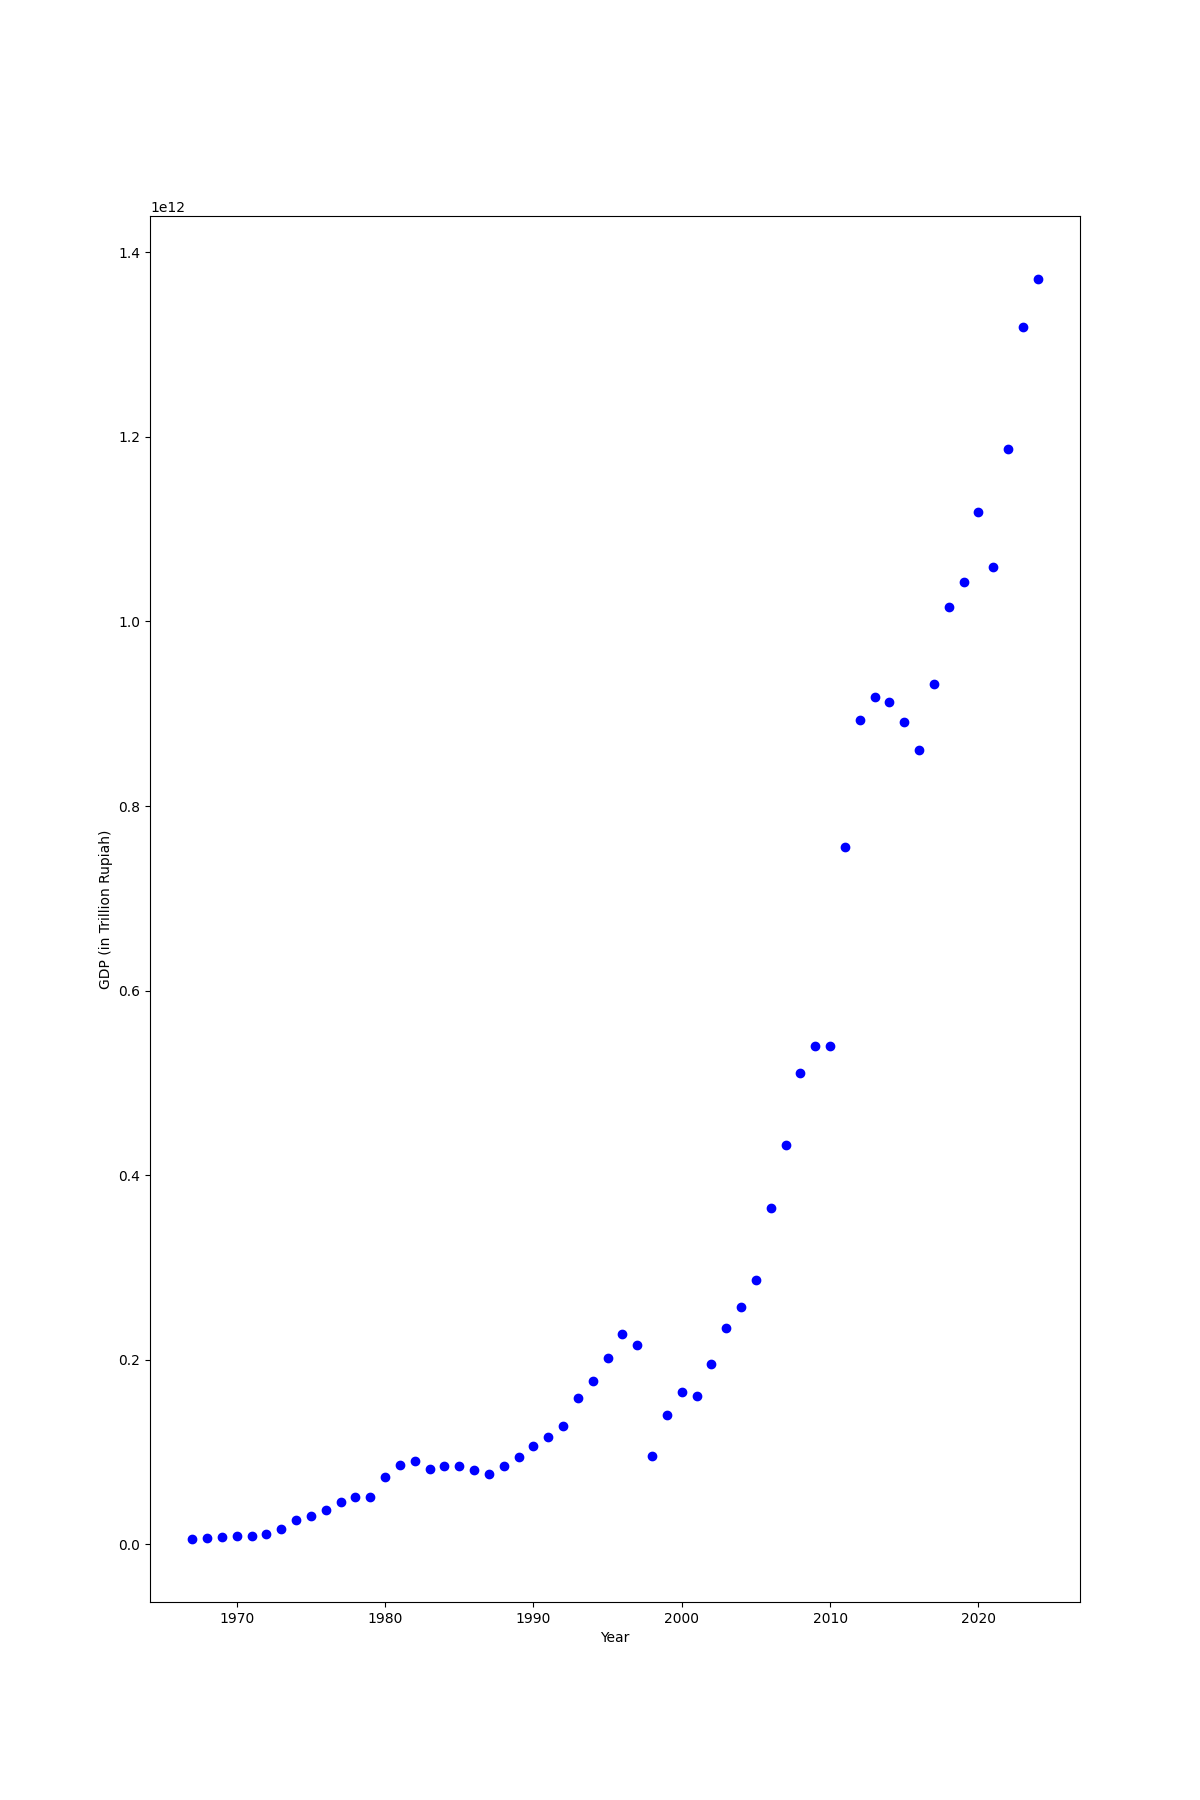

In [298]:

# Plotting menggunakan matplotlib
fig, ax = plt.subplots (figsize=(12, 18))

#for i in range (len (ax)):
#    ax[i].grid (True) 

ax.plot(data_GDP['Year'], data_GDP['GDP'], 'o', color='b')
ax.set_ylabel('GDP (in Trillion Rupiah)')

#ax[1].plot(data_GDP['Year'], data_GDP['GDP change'], marker='o', color='b')
#ax[1].set_ylabel('GDP change')

#ax[2].plot(data_GDP['Year'], data_GDP['GDP per capita'], marker='o', linestyle='-', color='b')
#ax[2].set_ylabel('GDP per capita')

#ax[0].set_title('GDP per Year')

plt.xlabel('Year')
plt.show()


In [299]:
import numpy as np
from scipy.interpolate import CubicSpline as cb
from numpy.polynomial.chebyshev import Chebyshev

In [300]:
# Data titik-titik yang diketahui
x_known = np.array (data_GDP['Year'])
y_known = np.array (data_GDP['GDP'])

In [301]:

# Interval dari titik-titik yang diketahui
a, b = x_known[0], x_known[-1]

# Menentukan Node Chebyshev
n = 20

x_k = np.cos((2 * np.arange(n + 1) + 1) * np.pi / (2 * (n + 1)))

# Memetakan Node Chebyshev ke interval yang diketahui
x_k_mapped = 0.5 * (a + b) + 0.5 * (b - a) * x_k
interpolate = cb (x_known, y_known)
y_k_mapped = interpolate (x_k_mapped)

# Menyesuaikan polinomial Chebyshev dengan titik-titik yang diketahui
chebyshev_poly = Chebyshev.fit (x_k_mapped, y_k_mapped , n)

In [302]:
for i in np.arange(2024.5, 2045.5, 0.5):
    
    x_known = np.append(x_known,i)
    y_known = np.append(y_known,chebyshev_poly(i))
    b = x_known[-1]
    n+=1
    x_k = np.cos((2 * np.arange(n + 1) + 1) * np.pi / (2 * (n + 1)))
    x_k_mapped = 0.5 * (a + b) + 0.5 * (b - a) * x_k
    y_k_mapped = chebyshev_poly(x_k_mapped)
    chebyshev_poly = Chebyshev.fit (x_k_mapped, y_k_mapped , n)

print(x_known)

[1967.  1968.  1969.  1970.  1971.  1972.  1973.  1974.  1975.  1976.
 1977.  1978.  1979.  1980.  1981.  1982.  1983.  1984.  1985.  1986.
 1987.  1988.  1989.  1990.  1991.  1992.  1993.  1994.  1995.  1996.
 1997.  1998.  1999.  2000.  2001.  2002.  2003.  2004.  2005.  2006.
 2007.  2008.  2009.  2010.  2011.  2012.  2013.  2014.  2015.  2016.
 2017.  2018.  2019.  2020.  2021.  2022.  2023.  2024.  2024.5 2025.
 2025.5 2026.  2026.5 2027.  2027.5 2028.  2028.5 2029.  2029.5 2030.
 2030.5 2031.  2031.5 2032.  2032.5 2033.  2033.5 2034.  2034.5 2035.
 2035.5 2036.  2036.5 2037.  2037.5 2038.  2038.5 2039.  2039.5 2040.
 2040.5 2041.  2041.5 2042.  2042.5 2043.  2043.5 2044.  2044.5 2045. ]


In [303]:
# Mengevaluasi polinomial pada interval yang diketahui
x_vals = np.linspace (a, b, 1000)
y_approx = chebyshev_poly (x_vals)

# Melakukan ekstrapolasi di luar interval yang diketahui
x_extrap = np.linspace (b, b + 1, 20)
y_extrap = chebyshev_poly (x_extrap)

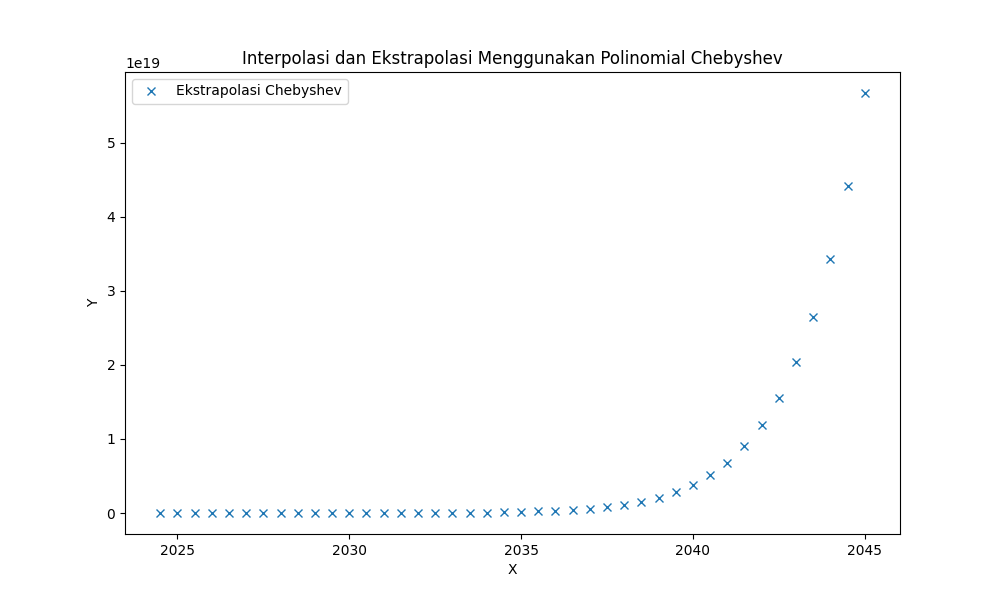

In [305]:
# Plot hasil
fig, ax1 = plt.subplots (figsize=(10, 6))
#ax1.plot (x_known[:58], y_known[:58], label='Titik-titik yang diketahui')
#ax1.plot (x_known[:58], interpolate (x_known[:58]), '-', label='interpolasi')
#ax1.plot (x_vals, y_approx, '-', label='Polinomial Chebyshev')
#ax1.plot (x_k_mapped,y_k_mapped, 'o', label='node Chebyshev')
ax1.plot (x_known[58:], y_known[58:], 'x', label='Ekstrapolasi Chebyshev')
ax1.legend ()
ax1.set_xlabel ('X')
ax1.set_ylabel ('Y')
ax1.set_title ('Interpolasi dan Ekstrapolasi Menggunakan Polinomial Chebyshev')
plt.show ()